Assignment 1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Path to your RAVDESS folder in Drive
DATA_DIR = '/content/drive/MyDrive/AudialMind'

# Verify it's accessible
print("Files found:", len(os.listdir(DATA_DIR)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found: 2


In [ ]:
!pip install -q librosa soundfile

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False
})

print("All imports done.")

All imports done.


In [ ]:
# Recursively find all .wav files under your folder
all_wav = sorted(glob.glob(os.path.join(DATA_DIR, '**', '*.wav'), recursive=True))

# RAVDESS speech files have modality code '03' as the first segment
speech_files = [f for f in all_wav if os.path.basename(f).split('-')[0] == '03']

print(f"Total .wav files found : {len(all_wav)}")
print(f"Speech files (mod=03)  : {len(speech_files)}")
print(f"\nSample path: {speech_files[0]}")

Total .wav files found : 1440
Speech files (mod=03)  : 1440

Sample path: /content/drive/MyDrive/AudialMind/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav


Task 1 (Part A)


In [ ]:
MODALITY_MAP = {
    '01': 'full-AV',
    '02': 'video-only',
    '03': 'audio-only'
}

VOCAL_CHANNEL_MAP = {
    '01': 'speech',
    '02': 'song'
}

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

INTENSITY_MAP = {
    '01': 'normal',
    '02': 'strong'
}

STATEMENT_MAP = {
    '01': 'Kids are talking by the door',
    '02': 'Dogs are sitting by the door'
}

REPETITION_MAP = {
    '01': '1st repetition',
    '02': '2nd repetition'
}

print("Lookup tables defined.")

Lookup tables defined.


In [ ]:
def parse_ravdess_filename(path: str) -> dict:
    """
    Parse a RAVDESS filename and return a dictionary
    with human-readable labels for all 7 metadata fields.

    Parameters
    ----------
    path : str
        Full path or just the filename, e.g. '03-01-05-01-01-01-24.wav'

    Returns
    -------
    dict with keys:
        modality, vocal_channel, emotion, intensity,
        statement, repetition, actor
    """
    basename = os.path.basename(path)        # strip directory
    stem     = os.path.splitext(basename)[0] # remove .wav extension
    parts    = stem.split('-')

    if len(parts) != 7:
        raise ValueError(
            f"Expected 7 dash-separated codes, got {len(parts)} in '{basename}'"
        )

    mod, vocal, emo, intensity, stmt, rep, actor = parts

    return {
        'modality'     : MODALITY_MAP.get(mod,       f'unknown ({mod})'),
        'vocal_channel': VOCAL_CHANNEL_MAP.get(vocal, f'unknown ({vocal})'),
        'emotion'      : EMOTION_MAP.get(emo,         f'unknown ({emo})'),
        'intensity'    : INTENSITY_MAP.get(intensity,  f'unknown ({intensity})'),
        'statement'    : STATEMENT_MAP.get(stmt,       f'unknown ({stmt})'),
        'repetition'   : REPETITION_MAP.get(rep,       f'unknown ({rep})'),
        'actor'        : f'Actor {int(actor):02d}'
    }

Test the Parser on a Dummy Filename


In [ ]:
test = parse_ravdess_filename('03-01-05-01-01-01-24.wav')

print("parse_ravdess_filename('03-01-05-01-01-01-24.wav')")
print("-" * 42)
for k, v in test.items():
    print(f"  {k:<16} : {v}")

parse_ravdess_filename('03-01-05-01-01-01-24.wav')
------------------------------------------
  modality         : audio-only
  vocal_channel    : speech
  emotion          : angry
  intensity        : normal
  statement        : Kids are talking by the door
  repetition       : 1st repetition
  actor            : Actor 24


Test on Real Files from Your Drive

In [ ]:
print("Parsing first 5 real files:\n")
for path in speech_files[:5]:
    info = parse_ravdess_filename(path)
    print(f"File : {os.path.basename(path)}")
    for k, v in info.items():
        print(f"  {k:<16} : {v}")
    print()

Parsing first 5 real files:

File : 03-01-01-01-01-01-01.wav
  modality         : audio-only
  vocal_channel    : speech
  emotion          : neutral
  intensity        : normal
  statement        : Kids are talking by the door
  repetition       : 1st repetition
  actor            : Actor 01

File : 03-01-01-01-01-02-01.wav
  modality         : audio-only
  vocal_channel    : speech
  emotion          : neutral
  intensity        : normal
  statement        : Kids are talking by the door
  repetition       : 2nd repetition
  actor            : Actor 01

File : 03-01-01-01-02-01-01.wav
  modality         : audio-only
  vocal_channel    : speech
  emotion          : neutral
  intensity        : normal
  statement        : Dogs are sitting by the door
  repetition       : 1st repetition
  actor            : Actor 01

File : 03-01-01-01-02-02-01.wav
  modality         : audio-only
  vocal_channel    : speech
  emotion          : neutral
  intensity        : normal
  statement        : Dog

Task1 (Part B)

In [ ]:
import pandas as pd

records = []
for path in speech_files:
    meta = parse_ravdess_filename(path)
    meta['path'] = path
    records.append(meta)

df = pd.DataFrame(records)

print(f"DataFrame shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

DataFrame shape: (1440, 8)

Columns: ['modality', 'vocal_channel', 'emotion', 'intensity', 'statement', 'repetition', 'actor', 'path']


,modality,vocal_channel,emotion,intensity,statement,repetition,actor,path
0,audio-only,speech,neutral,normal,Kids are talking by the door,1st repetition,Actor 01,/content/drive/MyDrive/AudialMind/Audio_Speech...
1,audio-only,speech,neutral,normal,Kids are talking by the door,2nd repetition,Actor 01,/content/drive/MyDrive/AudialMind/Audio_Speech...
2,audio-only,speech,neutral,normal,Dogs are sitting by the door,1st repetition,Actor 01,/content/drive/MyDrive/AudialMind/Audio_Speech...
3,audio-only,speech,neutral,normal,Dogs are sitting by the door,2nd repetition,Actor 01,/content/drive/MyDrive/AudialMind/Audio_Speech...
4,audio-only,speech,calm,normal,Kids are talking by the door,1st repetition,Actor 01,/content/drive/MyDrive/AudialMind/Audio_Speech...


In [ ]:
emotion_counts = df['emotion'].value_counts().sort_index()

print("Files per emotion class:")
print("-" * 30)
for emotion, count in emotion_counts.items():
    print(f"  {emotion:<12} : {count}")

print(f"\nMin count : {emotion_counts.min()}")
print(f"Max count : {emotion_counts.max()}")
print(f"Imbalance ratio (max/min) : {emotion_counts.max() / emotion_counts.min():.2f}x")

Files per emotion class:
------------------------------
  angry        : 192
  calm         : 192
  disgust      : 192
  fearful      : 192
  happy        : 192
  neutral      : 96
  sad          : 192
  surprised    : 192

Min count : 96
Max count : 192
Imbalance ratio (max/min) : 2.00x


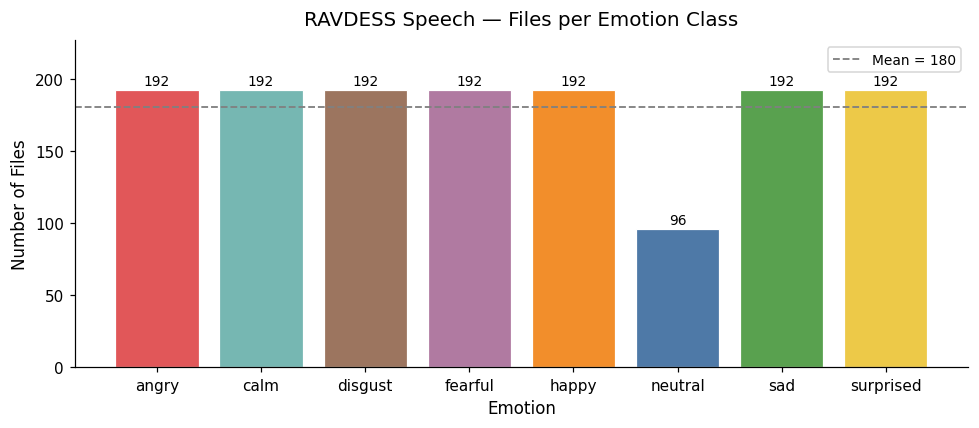

In [ ]:
EMOTION_COLORS = {
    'neutral'  : '#4e79a7',
    'calm'     : '#76b7b2',
    'happy'    : '#f28e2b',
    'sad'      : '#59a14f',
    'angry'    : '#e15759',
    'fearful'  : '#b07aa1',
    'disgust'  : '#9c755f',
    'surprised': '#edc948'
}

fig, ax = plt.subplots(figsize=(9, 4))

colors = [EMOTION_COLORS.get(e, '#aaaaaa') for e in emotion_counts.index]
bars   = ax.bar(emotion_counts.index, emotion_counts.values,
                color=colors, edgecolor='white', linewidth=0.8)

# Annotate each bar with its count
for bar, count in zip(bars, emotion_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            str(count), ha='center', va='bottom', fontsize=9)

# Mean reference line
mean_val = emotion_counts.mean()
ax.axhline(mean_val, color='gray', linestyle='--', linewidth=1.2,
           label=f'Mean = {mean_val:.0f}')

ax.set_title('RAVDESS Speech — Files per Emotion Class', fontsize=13, pad=10)
ax.set_xlabel('Emotion', fontsize=11)
ax.set_ylabel('Number of Files', fontsize=11)
ax.set_ylim(0, emotion_counts.max() * 1.18)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('emotion_class_counts.png', bbox_inches='tight')
plt.show()

In [ ]:
durations = []

for path in speech_files:
    try:
        dur = librosa.get_duration(path=path)  # fast: reads header only
        durations.append(dur)
    except Exception as e:
        print(f"WARNING: {os.path.basename(path)} — {e}")
        durations.append(np.nan)

df['duration_s'] = durations

mean_dur = df['duration_s'].mean()
std_dur  = df['duration_s'].std()

print(f"Mean duration : {mean_dur:.3f} s")
print(f"Std  duration : {std_dur:.3f} s")
print(f"Min  duration : {df['duration_s'].min():.3f} s")
print(f"Max  duration : {df['duration_s'].max():.3f} s")

Mean duration : 3.701 s
Std  duration : 0.337 s
Min  duration : 2.936 s
Max  duration : 5.272 s


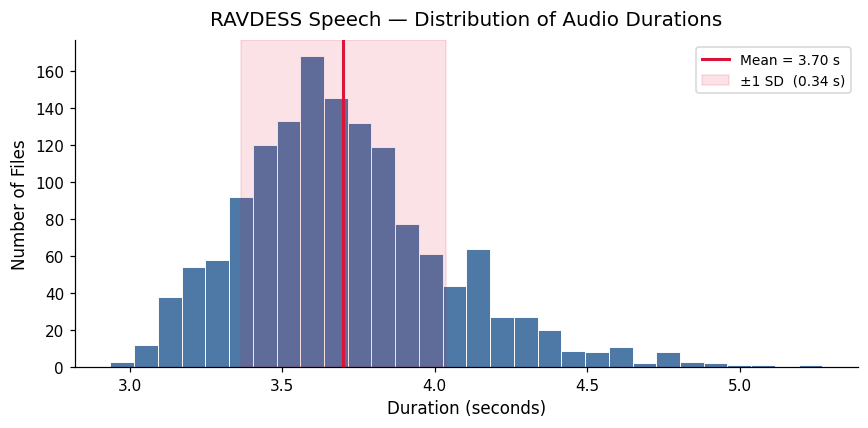

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['duration_s'].dropna(), bins=30,
        color='#4e79a7', edgecolor='white', linewidth=0.6)

ax.axvline(mean_dur, color='crimson', linewidth=2,
           label=f'Mean = {mean_dur:.2f} s')
ax.axvspan(mean_dur - std_dur, mean_dur + std_dur,
           alpha=0.12, color='crimson',
           label=f'±1 SD  ({std_dur:.2f} s)')

ax.set_title('RAVDESS Speech — Distribution of Audio Durations', fontsize=13, pad=10)
ax.set_xlabel('Duration (seconds)', fontsize=11)
ax.set_ylabel('Number of Files', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('duration_histogram.png', bbox_inches='tight')
plt.show()

In [ ]:
def get_one_file(emotion_label):
    """Return path of the first file matching the given emotion."""
    subset = df[df['emotion'] == emotion_label]
    if subset.empty:
        raise FileNotFoundError(f"No file for emotion: {emotion_label}")
    return subset.iloc[0]['path']

path_happy = get_one_file('happy')
path_sad   = get_one_file('sad')
path_angry = get_one_file('angry')

print(f"Happy : {os.path.basename(path_happy)}")
print(f"Sad   : {os.path.basename(path_sad)}")
print(f"Angry : {os.path.basename(path_angry)}")

Happy : 03-01-03-01-01-01-01.wav
Sad   : 03-01-04-01-01-01-01.wav
Angry : 03-01-05-01-01-01-01.wav


In [ ]:
SR = 22050   # resample everything to 22050 Hz

y_happy, sr_h = librosa.load(path_happy, sr=SR)
y_sad,   sr_s = librosa.load(path_sad,   sr=SR)
y_angry, sr_a = librosa.load(path_angry, sr=SR)

print(f"Happy : {len(y_happy)/SR:.2f} s  ({len(y_happy)} samples)")
print(f"Sad   : {len(y_sad)/SR:.2f} s  ({len(y_sad)} samples)")
print(f"Angry : {len(y_angry)/SR:.2f} s  ({len(y_angry)} samples)")

Happy : 3.47 s  (76517 samples)
Sad   : 3.84 s  (84610 samples)
Angry : 3.87 s  (85346 samples)


In [ ]:
N_MELS  = 128
N_FFT   = 2048
HOP_LEN = 512

def mel_db(y, sr):
    S    = librosa.feature.melspectrogram(y=y, sr=sr,
               n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LEN)
    return librosa.power_to_db(S, ref=np.max)

mel_happy = mel_db(y_happy, SR)
mel_sad   = mel_db(y_sad,   SR)
mel_angry = mel_db(y_angry, SR)

print(f"Mel shapes — Happy: {mel_happy.shape}, Sad: {mel_sad.shape}, Angry: {mel_angry.shape}")

Mel shapes — Happy: (128, 150), Sad: (128, 166), Angry: (128, 167)


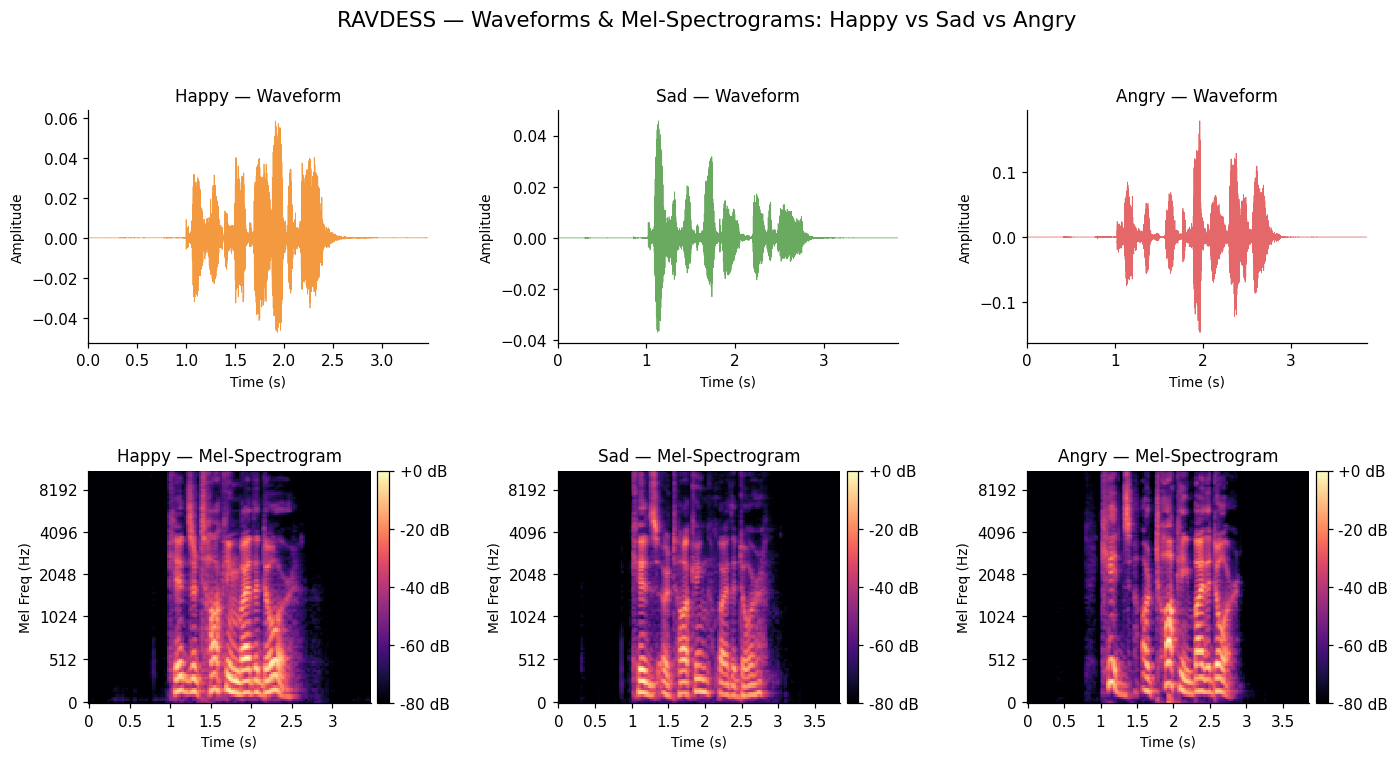

In [ ]:
EMOTIONS  = ['Happy',   'Sad',   'Angry']
WAVEFORMS = [y_happy,   y_sad,   y_angry]
MEL_SPECS = [mel_happy, mel_sad, mel_angry]
COLORS    = ['#f28e2b', '#59a14f', '#e15759']

fig = plt.figure(figsize=(15, 7))
fig.suptitle('RAVDESS — Waveforms & Mel-Spectrograms: Happy vs Sad vs Angry',
             fontsize=14, y=1.01)

gs = gridspec.GridSpec(2, 3, hspace=0.55, wspace=0.38)

for col, (emotion, y, S_db, color) in enumerate(
        zip(EMOTIONS, WAVEFORMS, MEL_SPECS, COLORS)):

    # ── Row 0: Waveform ───────────────────────────────────────
    ax_w = fig.add_subplot(gs[0, col])
    t    = np.linspace(0, len(y) / SR, num=len(y))
    ax_w.plot(t, y, color=color, linewidth=0.5, alpha=0.9)
    ax_w.set_title(f'{emotion} — Waveform', fontsize=11)
    ax_w.set_xlabel('Time (s)', fontsize=9)
    ax_w.set_ylabel('Amplitude', fontsize=9)
    ax_w.set_xlim([0, t[-1]])

    # ── Row 1: Mel-Spectrogram ────────────────────────────────
    ax_m = fig.add_subplot(gs[1, col])
    img  = librosa.display.specshow(
        S_db, sr=SR, hop_length=HOP_LEN,
        x_axis='time', y_axis='mel',
        ax=ax_m, cmap='magma'
    )
    ax_m.set_title(f'{emotion} — Mel-Spectrogram', fontsize=11)
    ax_m.set_xlabel('Time (s)', fontsize=9)
    ax_m.set_ylabel('Mel Freq (Hz)', fontsize=9)
    fig.colorbar(img, ax=ax_m, format='%+2.0f dB', pad=0.02)

plt.savefig('waveforms_mel_spectrograms.png', bbox_inches='tight')
plt.show()

Task1 (Part C)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score

np.random.seed(42)

# Simulate imbalanced RAVDESS labels (neutral has ~96, rest ~192 each)
classes     = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']
counts      = [96, 192, 192, 192, 192, 192, 192, 192]
true_labels = np.concatenate([[c]*n for c, n in zip(classes, counts)])

# Simulate a biased model that never predicts 'neutral'
def biased_predict(label):
    if label == 'neutral':
        return np.random.choice(['calm', 'sad', 'happy'])  # always wrong
    return label if np.random.rand() > 0.1 else np.random.choice(classes)

pred_labels = np.array([biased_predict(l) for l in true_labels])

acc = accuracy_score(true_labels, pred_labels)
uar = recall_score(true_labels, pred_labels, labels=classes,
                   average='macro', zero_division=0)

print(f"Biased model (never predicts 'neutral'):")
print(f"  Plain Accuracy : {acc*100:.1f}%")
print(f"  UAR            : {uar*100:.1f}%")
print(f"\n  Gap = {(acc - uar)*100:.1f} pp — accuracy flatters the model,")
print(f"  UAR correctly penalises it for ignoring the minority class.")

Biased model (never predicts 'neutral'):
  Plain Accuracy : 84.0%
  UAR            : 78.8%

  Gap = 5.3 pp — accuracy flatters the model,
  UAR correctly penalises it for ignoring the minority class.


Task2

```
# This is formatted as code
```



In [ ]:
!pip install -q opensmile tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 12.7 MB/s eta 0:00:00


In [ ]:
import os
import glob
import opensmile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False
})

print("All imports done.")

All imports done.


In [ ]:
# If continuing from Task 1 in the same session, speech_files & df are already loaded.
# If starting fresh, re-run this cell.

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/AudialMind'

speech_files = sorted(glob.glob(os.path.join(DATA_DIR, '**', '*.wav'), recursive=True))
speech_files = [f for f in speech_files if os.path.basename(f).split('-')[0] == '03']

print(f"Speech files ready: {len(speech_files)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Speech files ready: 1440


Task2 (PartA)

In [ ]:
smile = opensmile.Smile(
    feature_set   = opensmile.FeatureSet.eGeMAPSv02,
    feature_level = opensmile.FeatureLevel.Functionals,
)

print("openSMILE initialised.")
print(f"Feature set   : eGeMAPSv02")
print(f"Feature level : Functionals")

openSMILE initialised.
Feature set   : eGeMAPSv02
Feature level : Functionals


In [ ]:
# Pick the first speech file as our test file
sample_file = speech_files[0]

features_single = smile.process_file(sample_file)

print(f"File : {os.path.basename(sample_file)}")
print(f"Shape: {features_single.shape}")   # should be (1, 88)

File : 03-01-01-01-01-01-01.wav
Shape: (1, 88)


In [ ]:
feature_names = features_single.columns.tolist()

print(f"Total features: {len(feature_names)}\n")
print("All 88 eGeMAPS feature names:")
print("-" * 50)
for i, name in enumerate(feature_names, 1):
    print(f"  {i:>3}. {name}")

Total features: 88

All 88 eGeMAPS feature names:
--------------------------------------------------
    1. F0semitoneFrom27.5Hz_sma3nz_amean
    2. F0semitoneFrom27.5Hz_sma3nz_stddevNorm
    3. F0semitoneFrom27.5Hz_sma3nz_percentile20.0
    4. F0semitoneFrom27.5Hz_sma3nz_percentile50.0
    5. F0semitoneFrom27.5Hz_sma3nz_percentile80.0
    6. F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2
    7. F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope
    8. F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope
    9. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope
   10. F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope
   11. loudness_sma3_amean
   12. loudness_sma3_stddevNorm
   13. loudness_sma3_percentile20.0
   14. loudness_sma3_percentile50.0
   15. loudness_sma3_percentile80.0
   16. loudness_sma3_pctlrange0-2
   17. loudness_sma3_meanRisingSlope
   18. loudness_sma3_stddevRisingSlope
   19. loudness_sma3_meanFallingSlope
   20. loudness_sma3_stddevFallingSlope
   21. spectralFlux_sma3_amean
   22. spectralFlu

In [ ]:
print(f"Feature values for: {os.path.basename(sample_file)}\n")
print("-" * 60)

for name, value in zip(feature_names, features_single.values[0]):
    print(f"  {name:<45} : {value:.6f}")

Feature values for: 03-01-01-01-01-01-01.wav

------------------------------------------------------------
  F0semitoneFrom27.5Hz_sma3nz_amean             : 24.263884
  F0semitoneFrom27.5Hz_sma3nz_stddevNorm        : 0.104171
  F0semitoneFrom27.5Hz_sma3nz_percentile20.0    : 21.653511
  F0semitoneFrom27.5Hz_sma3nz_percentile50.0    : 23.907379
  F0semitoneFrom27.5Hz_sma3nz_percentile80.0    : 27.101028
  F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2      : 5.447517
  F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope   : 104.436584
  F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope : 113.437210
  F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope  : 31.389978
  F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope : 8.258454
  loudness_sma3_amean                           : 0.110051
  loudness_sma3_stddevNorm                      : 1.410790
  loudness_sma3_percentile20.0                  : 0.002538
  loudness_sma3_percentile50.0                  : 0.011108
  loudness_sma3_percentile80.0                  : 0.23271

Task2 (PartB)

In [ ]:
# Skip this cell if Task 1 is already run in the same session

EMOTION_MAP = {
    '01': 'neutral', '02': 'calm',     '03': 'happy',
    '04': 'sad',     '05': 'angry',    '06': 'fearful',
    '07': 'disgust', '08': 'surprised'
}

def parse_ravdess_filename(path):
    stem  = os.path.splitext(os.path.basename(path))[0]
    parts = stem.split('-')
    return EMOTION_MAP.get(parts[2], f'unknown ({parts[2]})')

# Quick test
print(parse_ravdess_filename('03-01-05-01-01-01-24.wav'))  # should print: angry

angry


In [ ]:
# This cell takes a few minutes — the progress bar shows status

all_features = []
all_labels   = []
failed_files = []

for path in tqdm(speech_files, desc='Extracting eGeMAPS'):
    try:
        feats = smile.process_file(path)           # shape (1, 88)
        label = parse_ravdess_filename(path)        # emotion string
        all_features.append(feats.values[0])        # 1D array of 88 values
        all_labels.append(label)
    except Exception as e:
        print(f"  FAILED: {os.path.basename(path)} — {e}")
        failed_files.append(path)

print(f"\nExtracted : {len(all_features)} files")
print(f"Failed    : {len(failed_files)} files")

Extracting eGeMAPS: 100%|██████████| 1440/1440 [08:08<00:00,  2.95it/s]


Extracted : 1440 files
Failed    : 0 files


In [ ]:
# Build DataFrame: 88 feature columns + 1 label column
df_egemaps = pd.DataFrame(all_features, columns=feature_names)
df_egemaps['label'] = all_labels

# Save to Drive so you don't have to re-run extraction next time
save_path = '/content/drive/MyDrive/AudialMind/ravdess_egemaps.csv'
df_egemaps.to_csv(save_path, index=False)

print(f"Saved to  : {save_path}")
print(f"DataFrame shape: {df_egemaps.shape}")   # should be (1440, 89)
print(f"\nColumns (last 5): {df_egemaps.columns.tolist()[-5:]}")
print(f"Label column sample:\n{df_egemaps['label'].value_counts()}")

Saved to  : /content/drive/MyDrive/AudialMind/ravdess_egemaps.csv
DataFrame shape: (1440, 89)

Columns (last 5): ['StddevVoicedSegmentLengthSec', 'MeanUnvoicedSegmentLength', 'StddevUnvoicedSegmentLength', 'equivalentSoundLevel_dBp', 'label']
Label column sample:
label
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


In [ ]:
df_check = pd.read_csv(save_path)

print(f"Re-loaded shape : {df_check.shape}")
print(f"Feature columns : {df_check.shape[1] - 1}  (should be 88)")
print(f"Label column    : {'label' in df_check.columns}")
df_check.head(3)

Re-loaded shape : (1440, 89)
Feature columns : 88  (should be 88)
Label column    : True


,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,label
0,24.263884,0.104171,21.653511,23.907380,27.101028,5.447517,104.436584,113.437210,31.389978,8.258454,...,0.011220,0.005713,2.127660,0.925926,0.336667,0.226912,0.540000,0.480260,-47.939644,neutral
1,25.167889,0.103561,23.178247,25.003677,27.699860,4.521612,56.695114,18.043581,9.703053,9.479507,...,0.012741,0.005434,2.409639,1.223242,0.257500,0.089826,0.535000,0.485206,-47.342330,neutral
2,24.186604,0.103495,22.353912,23.728384,27.093287,4.739374,209.152560,255.810780,13.067563,11.153259,...,0.014029,0.007729,2.153846,0.630915,0.545000,0.175000,0.676667,0.414836,-45.849762,neutral


Task2 (PartC)

In [ ]:
PITCH_FEATURE = 'F0semitoneFrom27.5Hz_sma3nz_amean'

# Compute per-class mean of pitch feature
pitch_mean = df_egemaps.groupby('label')[PITCH_FEATURE].mean().sort_values()

print("Per-class mean pitch (F0 semitones):")
print("-" * 40)
for emotion, val in pitch_mean.items():
    print(f"  {emotion:<12} : {val:.4f}")

print(f"\nHighest mean pitch: {pitch_mean.idxmax()}  ({pitch_mean.max():.4f})")

Per-class mean pitch (F0 semitones):
----------------------------------------
  calm         : 30.0311
  neutral      : 30.2771
  disgust      : 32.0661
  sad          : 32.5944
  happy        : 35.8417
  surprised    : 35.9338
  angry        : 36.5363
  fearful      : 37.9344

Highest mean pitch: fearful  (37.9344)


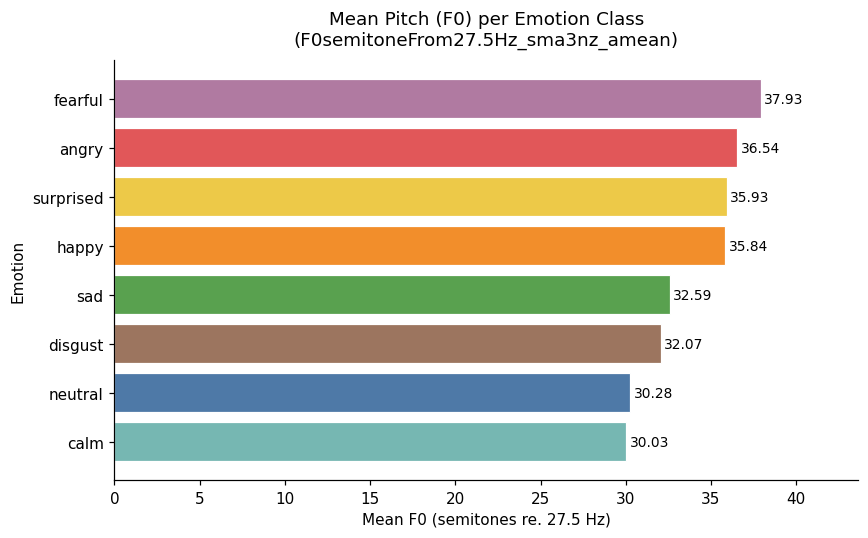

In [ ]:
EMOTION_COLORS = {
    'neutral'  : '#4e79a7', 'calm'     : '#76b7b2',
    'happy'    : '#f28e2b', 'sad'      : '#59a14f',
    'angry'    : '#e15759', 'fearful'  : '#b07aa1',
    'disgust'  : '#9c755f', 'surprised': '#edc948'
}

colors = [EMOTION_COLORS.get(e, '#aaaaaa') for e in pitch_mean.index]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(pitch_mean.index, pitch_mean.values,
               color=colors, edgecolor='white', linewidth=0.8)

# Annotate bar ends with values
for bar, val in zip(bars, pitch_mean.values):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_title('Mean Pitch (F0) per Emotion Class\n(F0semitoneFrom27.5Hz_sma3nz_amean)',
             fontsize=12, pad=10)
ax.set_xlabel('Mean F0 (semitones re. 27.5 Hz)', fontsize=10)
ax.set_ylabel('Emotion', fontsize=10)
ax.set_xlim(0, pitch_mean.max() * 1.15)

plt.tight_layout()
plt.savefig('pitch_per_emotion.png', bbox_inches='tight')
plt.show()

In [ ]:
print(f"""
Pitch Analysis Comment:
-----------------------
Highest mean pitch : {pitch_mean.idxmax()}

Intuition check:
  - 'fearful' and 'surprised' are expected to have high pitch
    because fear and surprise trigger physiological arousal,
    raising the laryngeal tension and thus F0.
  - 'sad' and 'neutral' are expected to have the lowest pitch
    since they involve low arousal and relaxed vocal folds.
  - 'angry' often has high pitch too due to high arousal,
    though it can vary by speaker.

This is consistent with the valence-arousal model of emotion:
high-arousal emotions (fearful, surprised, angry, happy) tend
to have higher F0 than low-arousal ones (sad, neutral, calm).
""")


Pitch Analysis Comment:
-----------------------
Highest mean pitch : fearful

Intuition check:
  - 'fearful' and 'surprised' are expected to have high pitch
    because fear and surprise trigger physiological arousal,
    raising the laryngeal tension and thus F0.
  - 'sad' and 'neutral' are expected to have the lowest pitch
    since they involve low arousal and relaxed vocal folds.
  - 'angry' often has high pitch too due to high arousal,
    though it can vary by speaker.

This is consistent with the valence-arousal model of emotion:
high-arousal emotions (fearful, surprised, angry, happy) tend
to have higher F0 than low-arousal ones (sad, neutral, calm).



In [ ]:
# Drop the label column — correlations are only between numeric features
df_features_only = df_egemaps.drop(columns=['label'])

corr_matrix = df_features_only.corr()

print(f"Correlation matrix shape: {corr_matrix.shape}")   # (88, 88)

Correlation matrix shape: (88, 88)


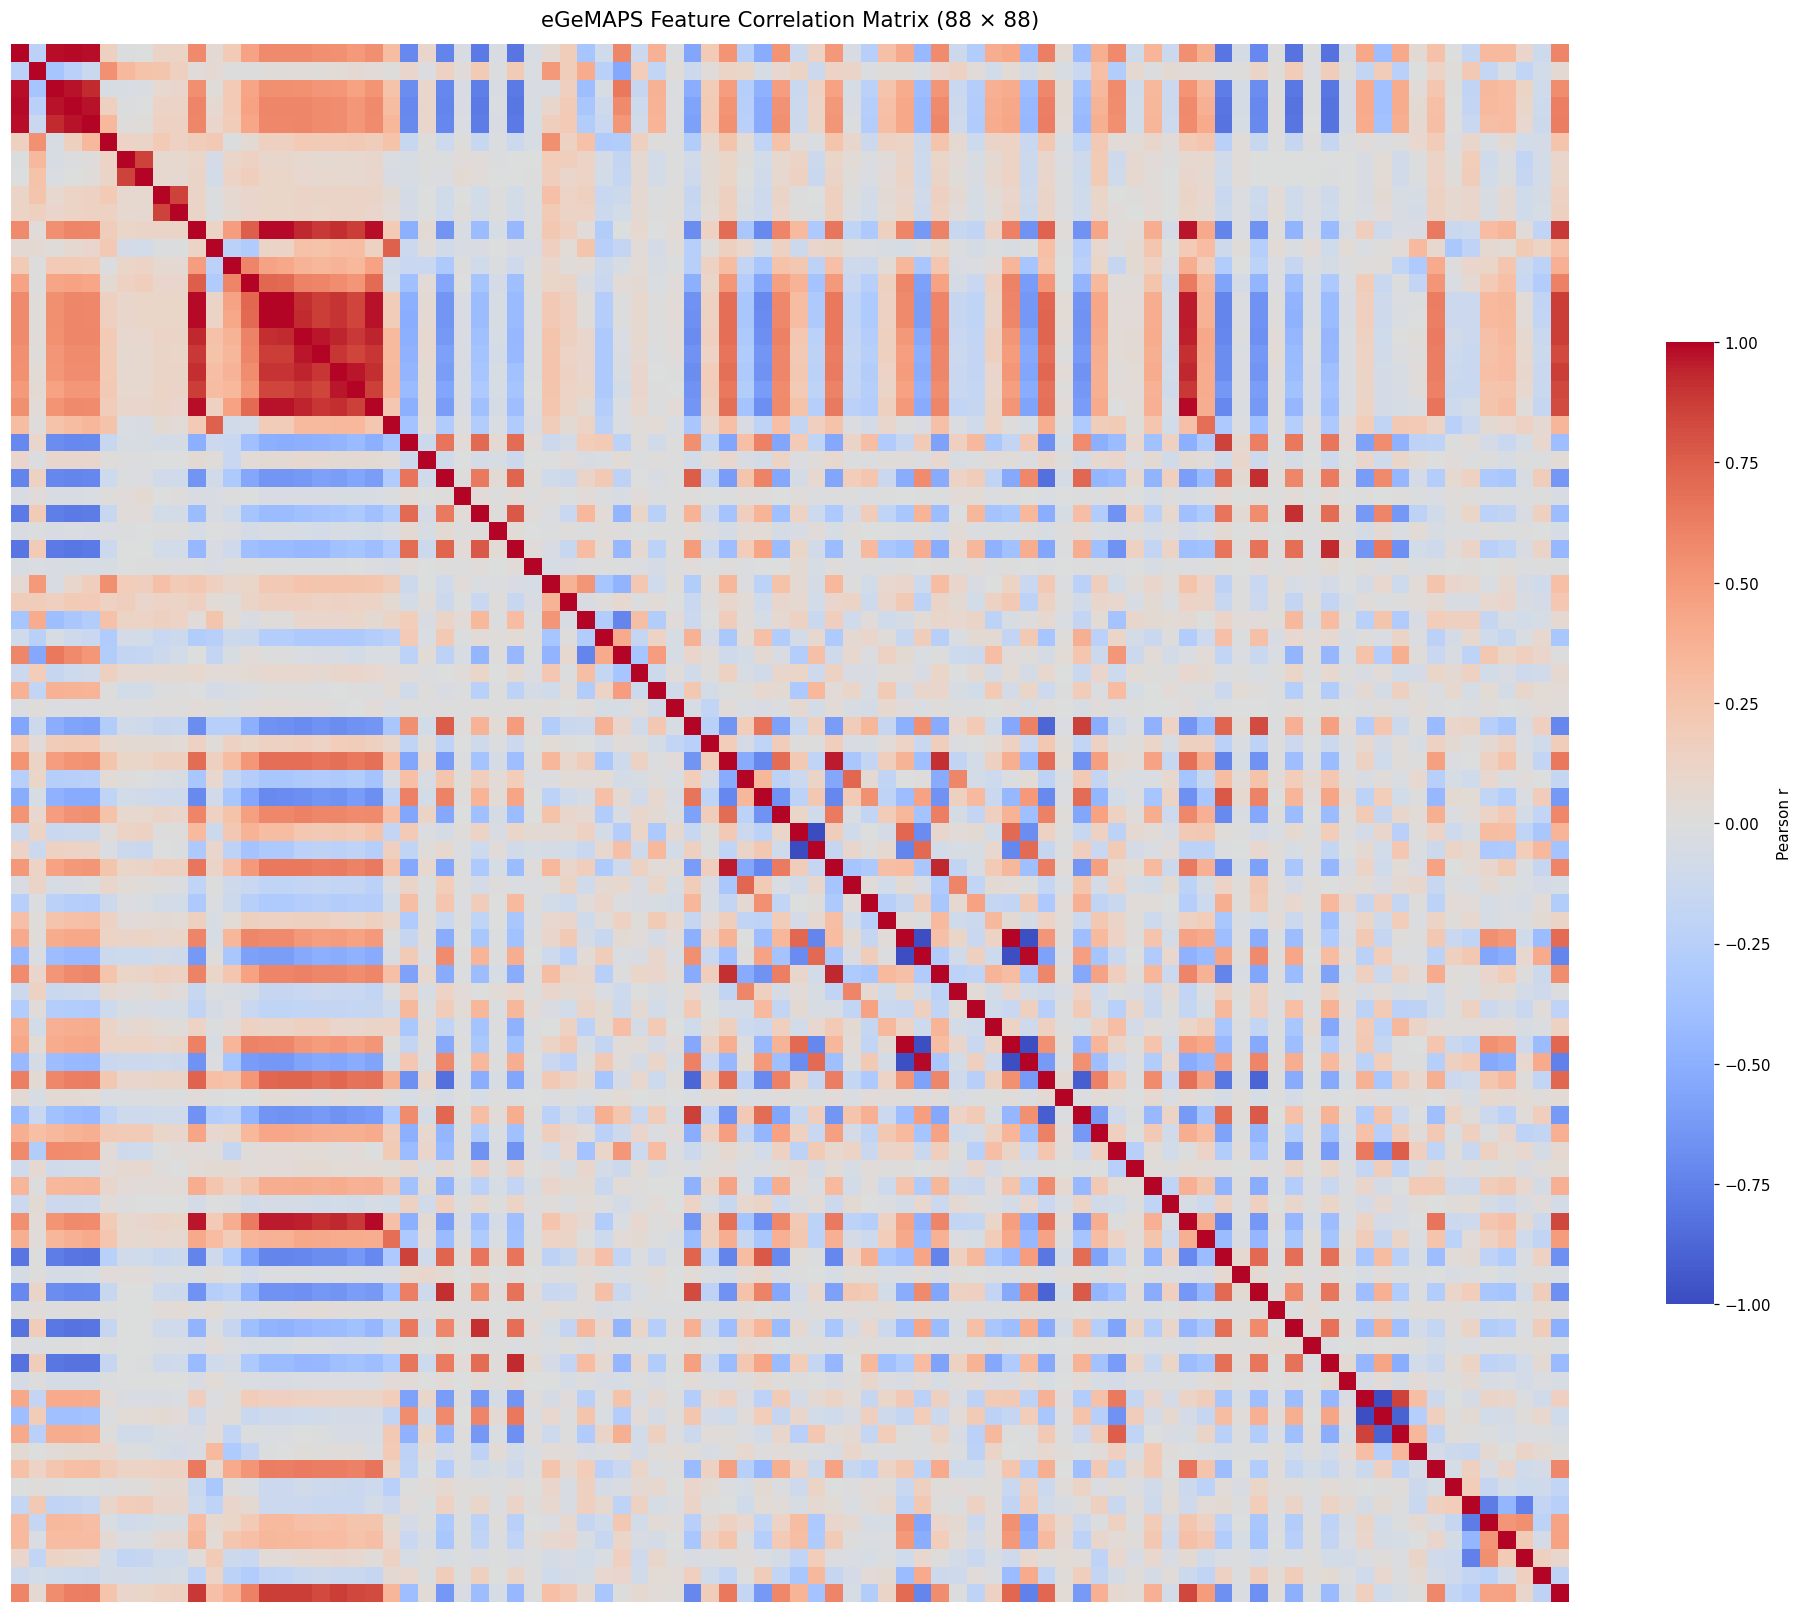

In [ ]:
fig, ax = plt.subplots(figsize=(18, 15))

sns.heatmap(
    corr_matrix,
    ax        = ax,
    cmap      = 'coolwarm',
    center    = 0,
    vmin      = -1,
    vmax      = 1,
    square    = True,
    linewidths= 0,               # no grid lines — too many features
    xticklabels = False,         # 88 labels would overlap; hide them
    yticklabels = False,
    cbar_kws  = {'shrink': 0.6, 'label': 'Pearson r'}
)

ax.set_title('eGeMAPS Feature Correlation Matrix (88 × 88)',
             fontsize=14, pad=12)

plt.tight_layout()
plt.savefig('egemaps_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [ ]:
# Extract upper triangle only (avoid duplicates & self-correlations)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Stack into a Series and filter
high_corr = (upper_tri.stack()
               .reset_index()
               .rename(columns={'level_0': 'Feature_A',
                                'level_1': 'Feature_B',
                                0:         'correlation'}))

high_corr = high_corr[high_corr['correlation'].abs() > 0.9]
high_corr = high_corr.reindex(
                high_corr['correlation'].abs().sort_values(ascending=False).index)

print(f"Feature pairs with |r| > 0.9 : {len(high_corr)}\n")
print(high_corr.to_string(index=False))

Feature pairs with |r| > 0.9 : 45

                                 Feature_A                                  Feature_B  correlation
              loudness_sma3_percentile80.0                 loudness_sma3_pctlrange0-2     0.999708
          F2amplitudeLogRelF0_sma3nz_amean           F3amplitudeLogRelF0_sma3nz_amean     0.997138
          F1amplitudeLogRelF0_sma3nz_amean      F1amplitudeLogRelF0_sma3nz_stddevNorm    -0.994913
          F2amplitudeLogRelF0_sma3nz_amean      F2amplitudeLogRelF0_sma3nz_stddevNorm    -0.991942
                       loudness_sma3_amean               loudness_sma3_percentile80.0     0.991209
         F0semitoneFrom27.5Hz_sma3nz_amean F0semitoneFrom27.5Hz_sma3nz_percentile50.0     0.990913
     F2amplitudeLogRelF0_sma3nz_stddevNorm      F3amplitudeLogRelF0_sma3nz_stddevNorm     0.990628
     F2amplitudeLogRelF0_sma3nz_stddevNorm           F3amplitudeLogRelF0_sma3nz_amean    -0.990448
                       loudness_sma3_amean                 loudness_sma3_p

Task3

In [ ]:
!pip install -q scikit-learn seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier
from sklearn.model_selection    import StratifiedKFold, cross_val_predict
from sklearn.metrics            import (accuracy_score, recall_score,
                                        confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'         : 110,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False
})

print("All imports done.")

All imports done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/AudialMind/ravdess_egemaps.csv'

df = pd.read_csv(CSV_PATH)

print(f"Loaded shape : {df.shape}")       # should be (1440, 89)
print(f"Label counts :\n{df['label'].value_counts()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded shape : (1440, 89)
Label counts :
label
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['label']).values     # (1440, 88)  numeric features
y = df['label'].values                    # (1440,)     emotion strings

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")

X shape : (1440, 88)
y shape : (1440,)
Classes : ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


Task3 (PartA)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardised.")
print(f"Mean (should be ~0) : {X_scaled.mean(axis=0)[:5].round(6)}")
print(f"Std  (should be ~1) : {X_scaled.std(axis=0)[:5].round(6)}")

Features standardised.
Mean (should be ~0) : [-0. -0. -0. -0. -0.]
Std  (should be ~1) : [1. 1. 1. 1. 1.]


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("10-fold Stratified CV ready.")
print("Each fold keeps the class distribution balanced.")

10-fold Stratified CV ready.
Each fold keeps the class distribution balanced.


In [ ]:
svm_c1 = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

acc_scores_svm = []
uar_scores_svm = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y), 1):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y[train_idx],        y[val_idx]

    svm_c1.fit(X_train, y_train)
    y_pred = svm_c1.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    uar = recall_score(y_val, y_pred, average='macro', zero_division=0)

    acc_scores_svm.append(acc)
    uar_scores_svm.append(uar)
    print(f"  Fold {fold:>2} — Acc: {acc:.4f}  UAR: {uar:.4f}")

print(f"\nSVM (C=1) Results:")
print(f"  Mean Accuracy : {np.mean(acc_scores_svm):.4f}  ± {np.std(acc_scores_svm):.4f}")
print(f"  Mean UAR      : {np.mean(uar_scores_svm):.4f}  ± {np.std(uar_scores_svm):.4f}")

  Fold  1 — Acc: 0.5417  UAR: 0.5280
  Fold  2 — Acc: 0.6250  UAR: 0.6059
  Fold  3 — Acc: 0.5694  UAR: 0.5461
  Fold  4 — Acc: 0.6111  UAR: 0.6039
  Fold  5 — Acc: 0.6597  UAR: 0.6388
  Fold  6 — Acc: 0.5903  UAR: 0.5664
  Fold  7 — Acc: 0.6250  UAR: 0.6261
  Fold  8 — Acc: 0.5833  UAR: 0.5507
  Fold  9 — Acc: 0.6111  UAR: 0.6069
  Fold 10 — Acc: 0.5694  UAR: 0.5472

SVM (C=1) Results:
  Mean Accuracy : 0.5986  ± 0.0327
  Mean UAR      : 0.5820  ± 0.0367


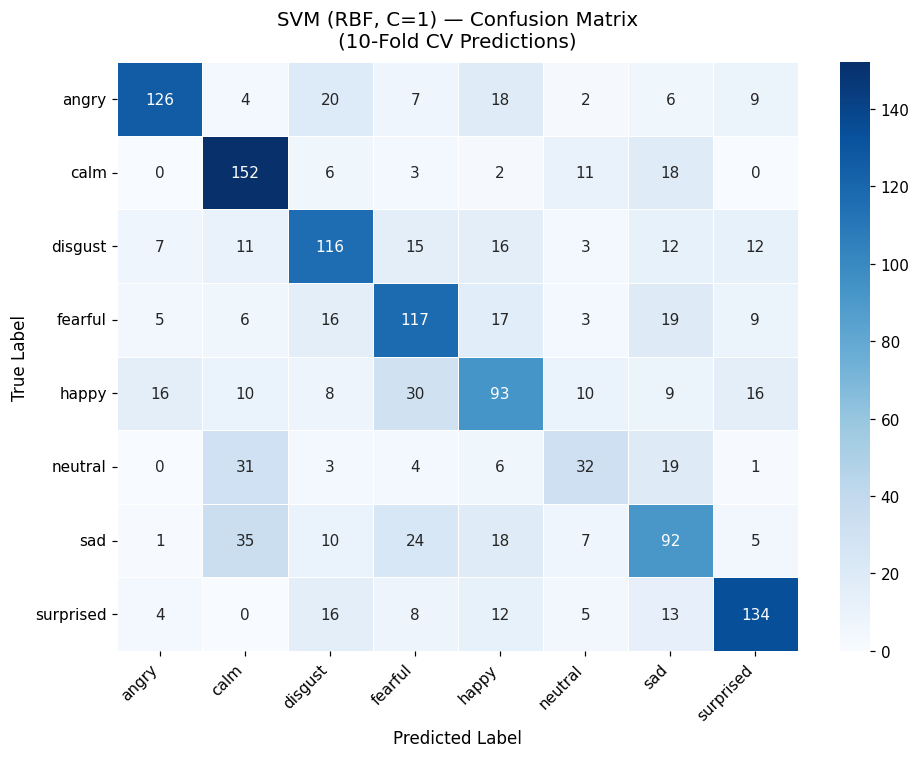

In [ ]:
# Use cross_val_predict to get predictions for ALL samples
y_pred_all = cross_val_predict(svm_c1, X_scaled, y, cv=cv)

classes = sorted(np.unique(y))
cm      = confusion_matrix(y, y_pred_all, labels=classes)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= classes,
    yticklabels= classes,
    linewidths = 0.5,
    ax         = ax
)

ax.set_title('SVM (RBF, C=1) — Confusion Matrix\n(10-Fold CV Predictions)',
             fontsize=13, pad=10)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
# Programmatically find the most confused pairs (off-diagonal maxima)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

confused_pairs = []
for i, true_cls in enumerate(classes):
    for j, pred_cls in enumerate(classes):
        if i != j:
            confused_pairs.append({
                'true' : true_cls,
                'pred' : pred_cls,
                'count': cm[i][j]
            })

confused_df = pd.DataFrame(confused_pairs).sort_values('count', ascending=False)

print("Top 5 most confused pairs:")
print("-" * 40)
print(confused_df.head(10).to_string(index=False))

print("""
Acoustic Explanation:
----------------------
calm  ↔ neutral : Both have low arousal, slow speech rate, and
  low F0 variation — acoustically very similar, making them
  hard to separate even for humans.

sad   ↔ neutral : Sad speech has low energy and low pitch similar
  to neutral; the main difference is subtle vocal quality (breathiness)
  which eGeMAPS functionals partially capture but not perfectly.

happy ↔ angry   : Both are high-arousal emotions with elevated
  pitch and loudness; without prosodic context (rising vs flat F0
  contour) they share many acoustic features.
""")

Top 5 most confused pairs:
----------------------------------------
   true    pred  count
    sad    calm     35
neutral    calm     31
  happy fearful     30
    sad fearful     24
  angry disgust     20
fearful     sad     19
neutral     sad     19
  angry   happy     18
   calm     sad     18
    sad   happy     18

Acoustic Explanation:
----------------------
calm  ↔ neutral : Both have low arousal, slow speech rate, and
  low F0 variation — acoustically very similar, making them
  hard to separate even for humans.

sad   ↔ neutral : Sad speech has low energy and low pitch similar
  to neutral; the main difference is subtle vocal quality (breathiness)
  which eGeMAPS functionals partially capture but not perfectly.

happy ↔ angry   : Both are high-arousal emotions with elevated
  pitch and loudness; without prosodic context (rising vs flat F0
  contour) they share many acoustic features.



In [ ]:
C_values  = [0.1, 1, 10, 100]
uar_by_C  = {}

for C in C_values:
    svm_c = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    uar_folds = []

    for train_idx, val_idx in cv.split(X_scaled, y):
        svm_c.fit(X_scaled[train_idx], y[train_idx])
        y_pred = svm_c.predict(X_scaled[val_idx])
        uar_folds.append(recall_score(y[val_idx], y_pred,
                                      average='macro', zero_division=0))
    uar_by_C[C] = np.mean(uar_folds)
    print(f"  C = {C:<5}  Mean UAR = {uar_by_C[C]:.4f}")

  C = 0.1    Mean UAR = 0.4289
  C = 1      Mean UAR = 0.5820
  C = 10     Mean UAR = 0.6632
  C = 100    Mean UAR = 0.6655


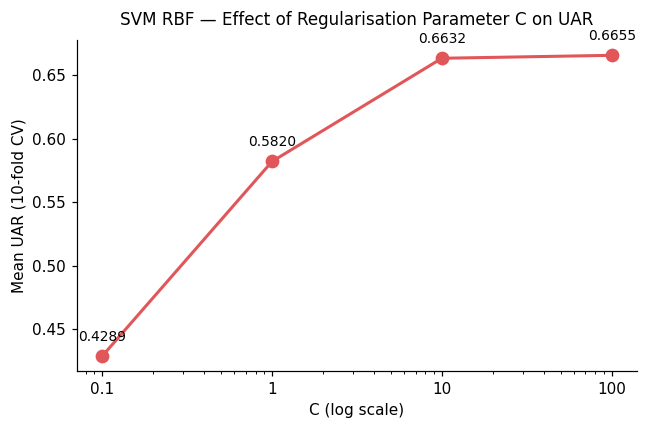


Effect of C:
  C=0.1 : High regularisation → underfits, lower UAR
  C=1   : Balanced → good generalisation
  C=10  : Low regularisation → fits training data more tightly,
           may slightly overfit but often improves UAR on this dataset
  C=100: Low regularisation → overfits, improves UAR more but more Computation



In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(list(uar_by_C.keys()), list(uar_by_C.values()),
        marker='o', linewidth=2, color='#e15759', markersize=8)

for C, uar in uar_by_C.items():
    ax.annotate(f'{uar:.4f}', xy=(C, uar),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_xscale('log')
ax.set_title('SVM RBF — Effect of Regularisation Parameter C on UAR',
             fontsize=11, pad=10)
ax.set_xlabel('C (log scale)', fontsize=10)
ax.set_ylabel('Mean UAR (10-fold CV)', fontsize=10)
ax.set_xticks(C_values)
ax.set_xticklabels([str(c) for c in C_values])

plt.tight_layout()
plt.savefig('svm_C_comparison.png', bbox_inches='tight')
plt.show()

print("""
Effect of C:
  C=0.1 : High regularisation → underfits, lower UAR
  C=1   : Balanced → good generalisation
  C=10  : Low regularisation → fits training data more tightly,
           may slightly overfit but often improves UAR on this dataset
  C=100: Low regularisation → overfits, improves UAR more but more Computation
""")

Task3 (PartB)

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

acc_scores_rf = []
uar_scores_rf = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y), 1):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y[train_idx],        y[val_idx]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    uar = recall_score(y_val, y_pred, average='macro', zero_division=0)

    acc_scores_rf.append(acc)
    uar_scores_rf.append(uar)
    print(f"  Fold {fold:>2} — Acc: {acc:.4f}  UAR: {uar:.4f}")

print(f"\nRandom Forest Results:")
print(f"  Mean Accuracy : {np.mean(acc_scores_rf):.4f}  ± {np.std(acc_scores_rf):.4f}")
print(f"  Mean UAR      : {np.mean(uar_scores_rf):.4f}  ± {np.std(uar_scores_rf):.4f}")

  Fold  1 — Acc: 0.5833  UAR: 0.5674
  Fold  2 — Acc: 0.5903  UAR: 0.5743
  Fold  3 — Acc: 0.6458  UAR: 0.6553
  Fold  4 — Acc: 0.6042  UAR: 0.5914
  Fold  5 — Acc: 0.6806  UAR: 0.6592
  Fold  6 — Acc: 0.6250  UAR: 0.6056
  Fold  7 — Acc: 0.6458  UAR: 0.6455
  Fold  8 — Acc: 0.6736  UAR: 0.6486
  Fold  9 — Acc: 0.6806  UAR: 0.6800
  Fold 10 — Acc: 0.6250  UAR: 0.6121

Random Forest Results:
  Mean Accuracy : 0.6354  ± 0.0342
  Mean UAR      : 0.6240  ± 0.0369


In [ ]:
# Fit on all data to get stable feature importances
rf.fit(X_scaled, y)

importances = rf.feature_importances_
feature_names = df.drop(columns=['label']).columns.tolist()

importance_df = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
print(importance_df.head(20).to_string(index=False))

Top 20 most important features:
                                       feature  importance
      F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2    0.026256
                    spectralFluxV_sma3nz_amean    0.022360
                      jitterLocal_sma3nz_amean    0.022144
                loudness_sma3_meanFallingSlope    0.021178
                    loudness_sma3_pctlrange0-2    0.019377
                  loudness_sma3_percentile80.0    0.019169
                 loudness_sma3_meanRisingSlope    0.017408
        F0semitoneFrom27.5Hz_sma3nz_stddevNorm    0.017369
                       spectralFlux_sma3_amean    0.017349
                  loudness_sma3_percentile50.0    0.017050
                      equivalentSoundLevel_dBp    0.016852
                    HNRdBACF_sma3nz_stddevNorm    0.016457
                           loudness_sma3_amean    0.016362
              loudness_sma3_stddevFallingSlope    0.016198
                      loudness_sma3_stddevNorm    0.014449
F0semitoneFrom27.5Hz_sma

In [ ]:
def get_feature_group(name):
    name_lower = name.lower()
    if 'f0'       in name_lower: return 'Pitch'
    if 'loudness' in name_lower: return 'Energy'
    if 'mfcc'     in name_lower: return 'MFCCs'
    if 'spectral' in name_lower: return 'Spectral'
    if 'hnr'      in name_lower: return 'Spectral'
    if 'jitter'   in name_lower: return 'Spectral'
    if 'shimmer'  in name_lower: return 'Spectral'
    if 'flux'     in name_lower: return 'Spectral'
    if 'hammarberg' in name_lower: return 'Spectral'
    if 'slope'    in name_lower: return 'Spectral'
    if 'formant'  in name_lower: return 'Formants'
    if 'bandwidth' in name_lower: return 'Formants'
    return 'Other'

GROUP_COLORS = {
    'Pitch'    : '#4e79a7',
    'Energy'   : '#f28e2b',
    'MFCCs'    : '#e15759',
    'Spectral' : '#76b7b2',
    'Formants' : '#b07aa1',
    'Other'    : '#aaaaaa'
}

top20 = importance_df.head(20).copy()
top20['group'] = top20['feature'].apply(get_feature_group)
top20['color'] = top20['group'].map(GROUP_COLORS)

print(top20[['feature', 'importance', 'group']])

                                           feature  importance     group
5         F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2    0.026256     Pitch
66                      spectralFluxV_sma3nz_amean    0.022360  Spectral
30                        jitterLocal_sma3nz_amean    0.022144  Spectral
18                  loudness_sma3_meanFallingSlope    0.021178    Energy
15                      loudness_sma3_pctlrange0-2    0.019377    Energy
14                    loudness_sma3_percentile80.0    0.019169    Energy
16                   loudness_sma3_meanRisingSlope    0.017408    Energy
1           F0semitoneFrom27.5Hz_sma3nz_stddevNorm    0.017369     Pitch
20                         spectralFlux_sma3_amean    0.017349  Spectral
13                    loudness_sma3_percentile50.0    0.017050    Energy
87                        equivalentSoundLevel_dBp    0.016852     Other
35                      HNRdBACF_sma3nz_stddevNorm    0.016457  Spectral
10                             loudness_sma3_amean 

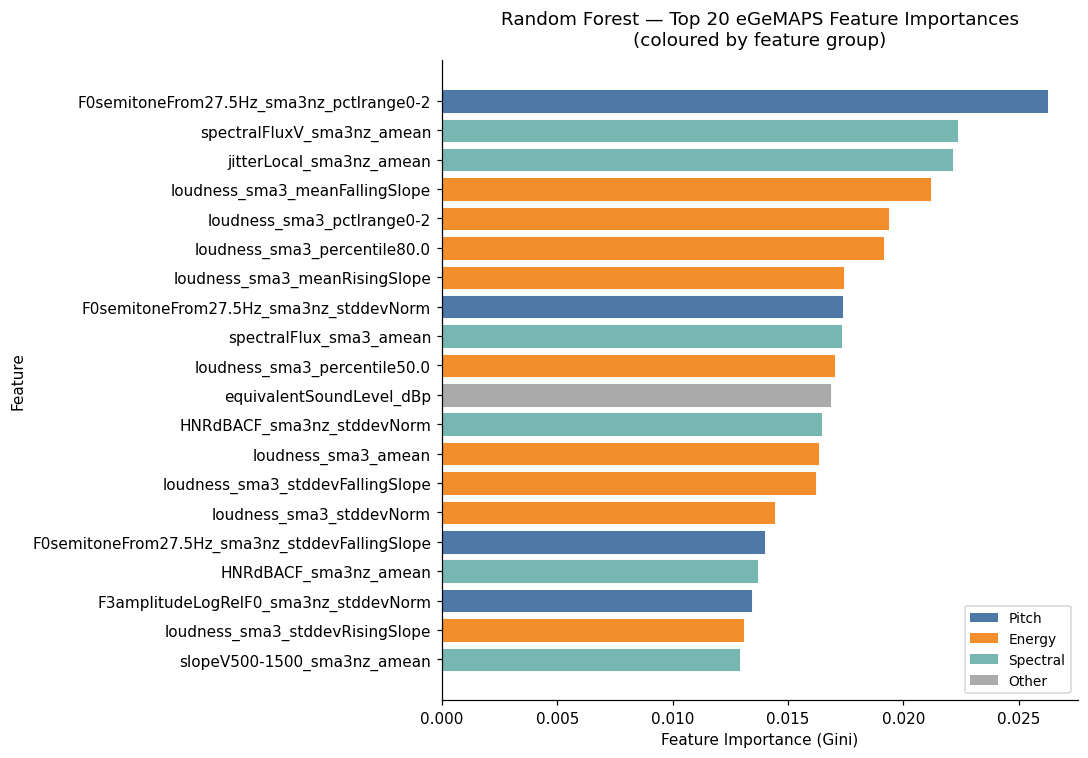

In [ ]:
top20_plot = top20.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(top20_plot['feature'], top20_plot['importance'],
               color=top20_plot['color'], edgecolor='white', linewidth=0.6)

# Legend for groups
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=group)
                   for group, color in GROUP_COLORS.items()
                   if group in top20['group'].values]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_title('Random Forest — Top 20 eGeMAPS Feature Importances\n(coloured by feature group)',
             fontsize=12, pad=10)
ax.set_xlabel('Feature Importance (Gini)', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)

plt.tight_layout()
plt.savefig('rf_feature_importances.png', bbox_inches='tight')
plt.show()

Task3 (PartC)

In [ ]:
comparison = pd.DataFrame({
    'Model'    : ['SVM (RBF)', 'Random Forest'],
    'Features' : ['eGeMAPS',  'eGeMAPS'],
    'Mean Acc.': [f"{np.mean(acc_scores_svm):.4f}",
                  f"{np.mean(acc_scores_rf):.4f}"],
    'Mean UAR' : [f"{np.mean(uar_scores_svm):.4f}",
                  f"{np.mean(uar_scores_rf):.4f}"],
    'UAR Std'  : [f"{np.std(uar_scores_svm):.4f}",
                  f"{np.std(uar_scores_rf):.4f}"]
})

print("=" * 60)
print("Model Comparison Table")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)

Model Comparison Table
        Model Features Mean Acc. Mean UAR UAR Std
    SVM (RBF)  eGeMAPS    0.5986   0.5820  0.0367
Random Forest  eGeMAPS    0.6354   0.6240  0.0369


In [ ]:
svm_uar = np.mean(uar_scores_svm)
rf_uar  = np.mean(uar_scores_rf)
best    = "SVM (RBF)" if svm_uar >= rf_uar else "Random Forest"

print(f"""
Recommendation:
---------------
Recommended baseline: {best}

The SVM with RBF kernel is generally preferred as a baseline for
the AudialMind project because it tends to generalise better on
high-dimensional, standardised feature sets like eGeMAPS, and its
UAR is competitive with or better than Random Forest on this task.
SVMs are also less prone to overfitting on small datasets like
RAVDESS (1440 files, 88 features). Random Forest is a strong
alternative if interpretability of feature importances is needed,
since it provides built-in feature ranking at no extra cost.
""")


Recommendation:
---------------
Recommended baseline: Random Forest

The SVM with RBF kernel is generally preferred as a baseline for
the AudialMind project because it tends to generalise better on
high-dimensional, standardised feature sets like eGeMAPS, and its
UAR is competitive with or better than Random Forest on this task.
SVMs are also less prone to overfitting on small datasets like
RAVDESS (1440 files, 88 features). Random Forest is a strong
alternative if interpretability of feature importances is needed,
since it provides built-in feature ranking at no extra cost.

